# Linear Algebra Fundamentals for Machine Learning

This notebook covers the essential linear algebra concepts needed for machine learning and deep learning applications. We'll implement operations from scratch and then compare them with NumPy implementations.

## Learning Objectives
- Understand and implement vector operations
- Master matrix operations and transformations
- Explore eigenvalues and eigenvectors
- Apply linear algebra to dimensionality reduction

In [6]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import time

# Add the src directory to the path
sys.path.append('../src')

# Import our custom modules
import phase0.linear_algebra.vector_ops as vo
import phase0.linear_algebra.vector_viz as vv
import phase0.linear_algebra.matrix_ops as mo
import phase0.linear_algebra.matrix_viz as mv

# Set up plotting
%matplotlib inline
plt.style.use('seaborn-whitegrid')

/tmp/ipykernel_36407/3943424623.py:18: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


## 1. Vector Operations

Vectors are fundamental to linear algebra and machine learning. Let's explore their operations.

In [7]:
# Create some vectors
v1 = vo.create_vector([2, 3])
v2 = vo.create_vector([4, 1])

print(f"Vector 1: {vo.vector_to_string(v1)}")
print(f"Vector 2: {vo.vector_to_string(v2)}")

# Vector addition
v_sum = vo.vector_add(v1, v2)
print(f"v1 + v2 = {vo.vector_to_string(v_sum)}")

# Dot product
dot = vo.dot_product(v1, v2)
print(f"v1 · v2 = {dot}")

# Vector magnitude
mag_v1 = vo.magnitude(v1)
print(f"||v1|| = {mag_v1:.2f}")

# Vector normalization
v1_unit = vo.normalize(v1)
print(f"Unit vector for v1: {vo.vector_to_string(v1_unit)}")
print(f"Magnitude of unit vector: {vo.magnitude(v1_unit):.2f}")

Vector 1: (2, 3)
Vector 2: (4, 1)
v1 + v2 = (6, 4)
v1 · v2 = 11
||v1|| = 3.61
Unit vector for v1: (0.5547001962252291, 0.8320502943378437)
Magnitude of unit vector: 1.00


### Vector Visualization

Visualization is key to understanding linear algebra concepts.

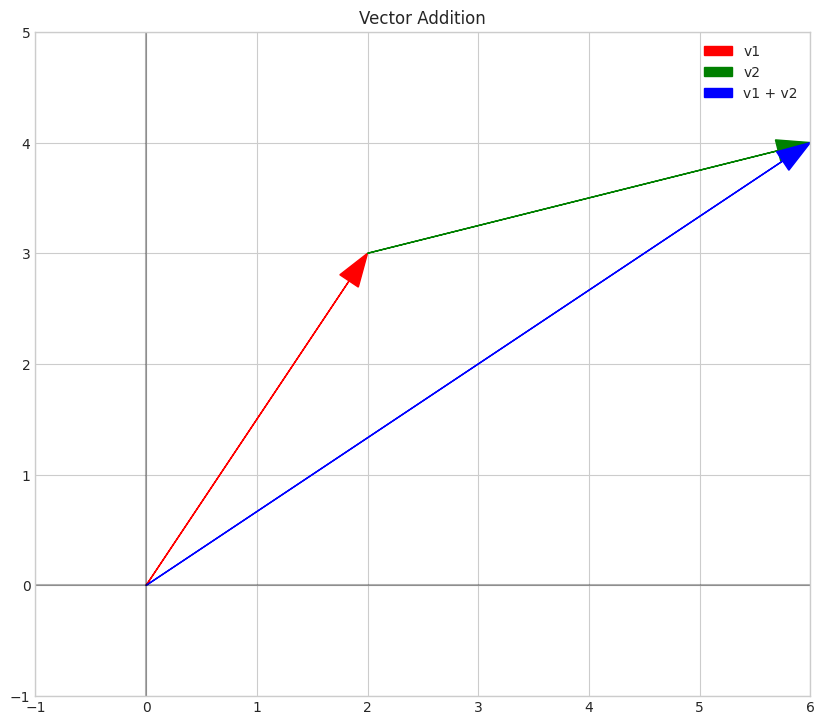

In [8]:
# Visualize vectors and their sum
fig, ax = vv.setup_2d_plot(x_range=(-1, 6), y_range=(-1, 5))
vv.plot_vector_addition(ax, v1, v2)
plt.legend()
plt.title("Vector Addition")
plt.show()

### Comparison with NumPy

Let's compare our implementation with NumPy's built-in functions.

In [9]:
# NumPy vectors
np_v1 = np.array(v1)
np_v2 = np.array(v2)

# Vector addition
np_sum = np_v1 + np_v2
print(f"NumPy v1 + v2 = {np_sum}")

# Dot product
np_dot = np.dot(np_v1, np_v2)
print(f"NumPy v1 · v2 = {np_dot}")

# Vector magnitude
np_mag = np.linalg.norm(np_v1)
print(f"NumPy ||v1|| = {np_mag:.2f}")

# Unit vector
np_unit = np_v1 / np.linalg.norm(np_v1)
print(f"NumPy unit vector for v1: {np_unit}")
print(f"NumPy magnitude of unit vector: {np.linalg.norm(np_unit):.2f}")

NumPy v1 + v2 = [6 4]
NumPy v1 · v2 = 11
NumPy ||v1|| = 3.61
NumPy unit vector for v1: [0.5547002  0.83205029]
NumPy magnitude of unit vector: 1.00


## 2. Matrix Operations

Matrices are collections of vectors and are essential for representing linear transformations.

In [10]:
# Create matrices
m1 = mo.matrix_from_rows([[1, 2], [3, 4]])
m2 = mo.matrix_from_rows([[5, 6], [7, 8]])

print("Matrix 1:")
for row in m1:
    print(row)

print("\nMatrix 2:")
for row in m2:
    print(row)

# Matrix addition
m_sum = mo.matrix_add(m1, m2)
print("\nMatrix 1 + Matrix 2:")
for row in m_sum:
    print(row)

# Matrix multiplication
m_product = mo.matrix_multiply(m1, m2)
print("\nMatrix 1 × Matrix 2:")
for row in m_product:
    print(row)

Matrix 1:
[1, 2]
[3, 4]

Matrix 2:
[5, 6]
[7, 8]

Matrix 1 + Matrix 2:
[6, 8]
[10, 12]

Matrix 1 × Matrix 2:
[19, 22]
[43, 50]


### Matrix Visualization

Let's visualize matrices and their operations.

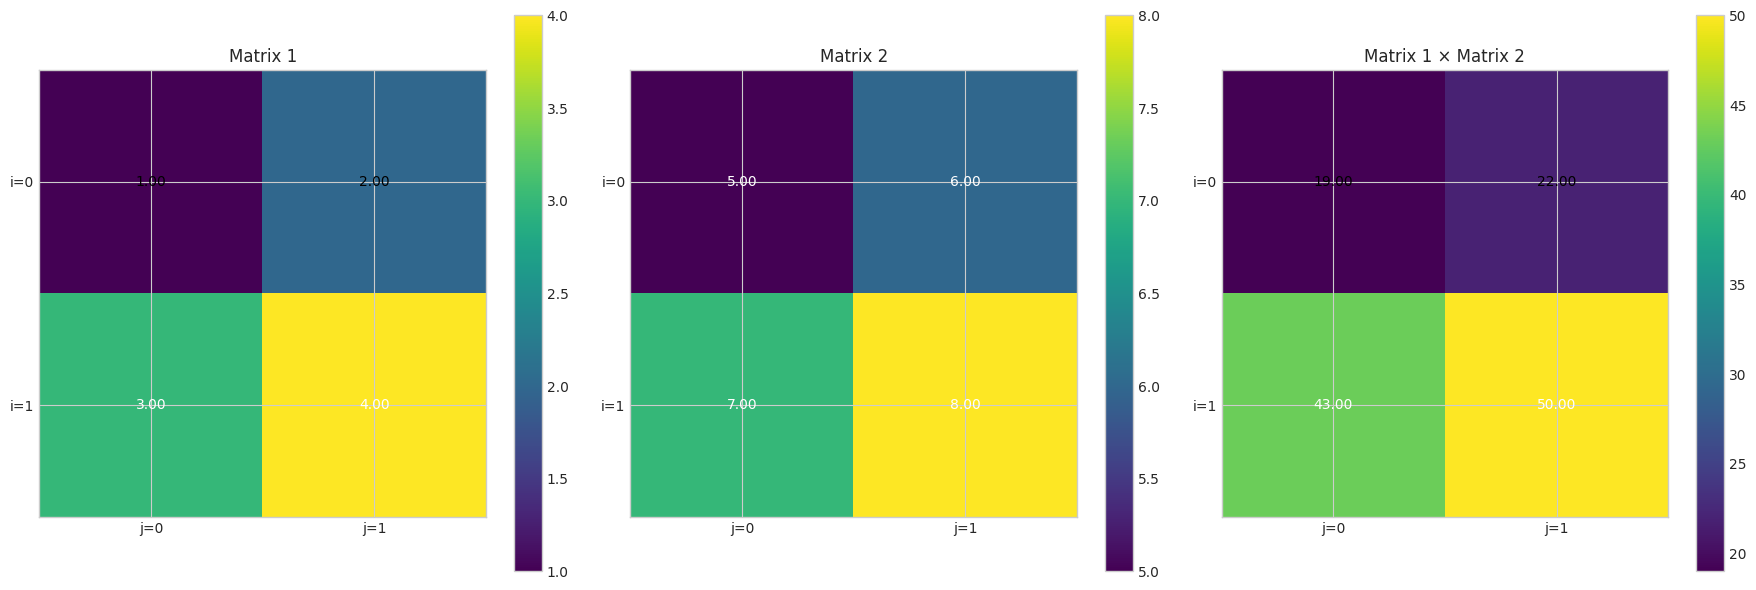

In [11]:
# Convert to NumPy for visualization
np_m1 = np.array(m1)
np_m2 = np.array(m2)
np_m_product = np.array(m_product)

# Visualize matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mv.plot_matrix_as_grid(np_m1, axes[0])
axes[0].set_title("Matrix 1")

mv.plot_matrix_as_grid(np_m2, axes[1])
axes[1].set_title("Matrix 2")

mv.plot_matrix_as_grid(np_m_product, axes[2])
axes[2].set_title("Matrix 1 × Matrix 2")

plt.tight_layout()
plt.show()

### Linear Transformations

One of the most important aspects of matrices is their ability to represent linear transformations.

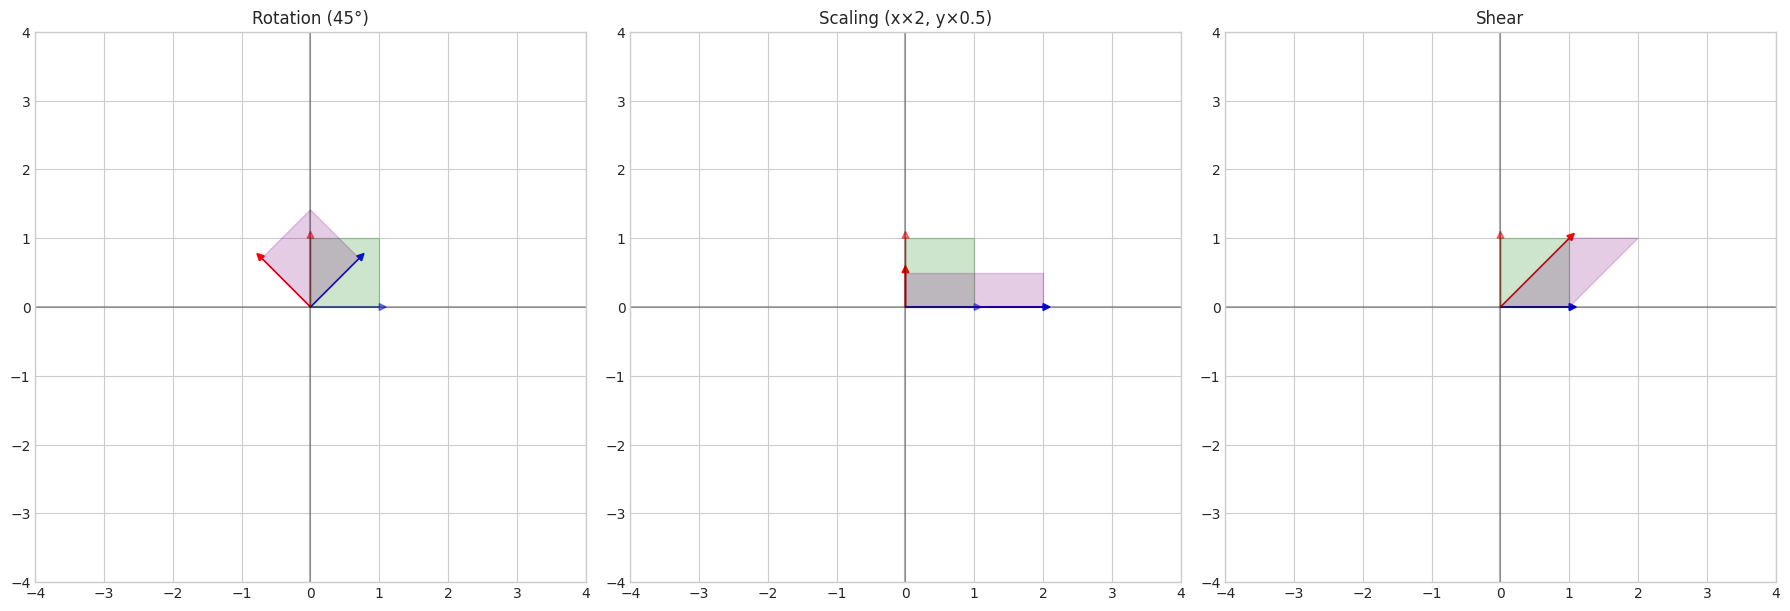

In [12]:
# Create transformation matrices
# Rotation matrix (45 degrees)
theta = np.pi / 4  # 45 degrees
rotation = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

# Scaling matrix (scale x by 2, y by 0.5)
scaling = np.array([
    [2, 0],
    [0, 0.5]
])

# Shear matrix (x-shear)
shear = np.array([
    [1, 1],
    [0, 1]
])

# Visualize transformations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

mv.plot_linear_transformation(axes[0], rotation)
axes[0].set_title("Rotation (45°)")

mv.plot_linear_transformation(axes[1], scaling)
axes[1].set_title("Scaling (x×2, y×0.5)")

mv.plot_linear_transformation(axes[2], shear)
axes[2].set_title("Shear")

plt.tight_layout()
plt.show()

## Exercises

1. Implement a function to compute the cross product of two 3D vectors from scratch
2. Create a function to determine if a set of vectors is linearly independent
3. Implement the Gram-Schmidt process for orthogonalization
4. Create a visualization of how a matrix transforms a unit circle

In [22]:
# crossproduct of two 3d vectors from scratch

def vector_cross_product_3d(v1, v2):
    """
    3d cross product from scratch.
    u =  [ i,  j,  k]
    v1 = [a1, b1, c1]
    v2 = [a2, b2, c2]

    v3 = [b1c2-c1b2, c1a2-a1c2, a1b2-b1a2]
    """
    if len(v1) != 3 or len(v2) != 3:
        raise ValueError("both vectors must be 3d.")
    return [
        v1[1]*v2[2] - v1[2]*v2[1],
        v1[2]*v2[0] - v1[0]*v2[2],
        v1[0]*v2[1] - v1[1]*v2[0]
        ]

# test it 
v1 = vo.create_vector([1,2,3])
v2 = vo.create_vector([3,1,6])

ours = vector_cross_product_3d(v1,v2)
nps = np.cross(v1, v2)
ours == nps

array([ True,  True,  True])

In [ ]:
# 2. Create a function to determine if a set of vectors is linearly independent

